# M2 (reworked) — soft operational regions on the Gaussian-copula map

This notebook reworks the FACE M2 stratification as a **continuum with soft operational regions** built on
the certified cohort-weighted full-N **Gaussian-copula** 9-dim map. It (1) loads (or recomputes) the staged
soft-region engine, (2) shows the **continuum** structure verdict, the **soft operational regions** (a
measurement-error tessellation) and the **archetype** continuum co-view, (3) makes the **soft-transition
boundaries** explicit (membership entropy, confidence tiers, boundary patients), and (4) reports the
**internal usefulness** battery — are the regions actually assignable, biology-driven, transdiagnostic,
stable, and tighter than DSM-5? (Temporal persistence and prognosis are deferred to the M3/M4 reruns.)

Invariants: no imputation (uncertainty propagates; substance=DR self-down-weights); diagnosis is
validation-only; UMAP/PCA are visualization-only; the copula map is fixed (no re-fit).

In [1]:
# Setup
from __future__ import annotations
from pathlib import Path
import sys
import numpy as np, pandas as pd
from IPython.display import Image, display

START = Path.cwd().resolve()
for cand in (START, *START.parents):
    if (cand / "src" / "face" / "strata").exists():
        REPO = cand; break
else:
    raise RuntimeError("repo root not found")
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
for m in [n for n in list(sys.modules) if n == "face" or n.startswith("face.")]:
    if getattr(sys.modules[m], "__file__", None) and SRC not in Path(sys.modules[m].__file__).resolve().parents:
        del sys.modules[m]

from face.strata.strata_model_oop import StrataConfig, StrataRunner, StrataVisualizer
print("repo:", REPO)

repo: /Users/andriikulakovskyi/Desktop/face-common-bp-sz-dr


## 1. Configure — load the cached strata, or recompute

`MODE = "load_certified"` reads the cached stage artifacts from `results/face/strata_oop/`.
`MODE = "recompute"` re-runs the full deterministic plan (coordinates → structure → regions → archetypes →
usefulness → consolidate) on the copula map — a few minutes of CPU.

In [2]:
MODE = "load_certified"          # "load_certified" | "recompute"
config = StrataConfig()
runner = StrataRunner(config)
viz = StrataVisualizer(config)
MODE, str(config.output_dir)

('load_certified',
 '/Users/andriikulakovskyi/Desktop/face-common-bp-sz-dr/results/face/strata_oop')

## 2. Load (or run) the staged engine

In [3]:
if MODE == "recompute":
    state = runner.run_plan(n_perm=30, overwrite=False)
else:
    state = runner.load_state()
    if "region_A" not in state:
        raise SystemExit("no cache — run `python notebooks/run_strata_model_oop.py --mode full` first, or set MODE='recompute'")
coords = state["coords"]
print(f"N={coords.X.shape[0]:,} patients on {len(coords.dims)} axes")
list(state)

N=9,013 patients on 9 axes


['coords',
 'structure',
 'region_A',
 'region_B',
 'choose_K',
 'arch_A',
 'arch_B',
 'select_A',
 'usefulness',
 'patient_strata']

## 3. Structure verdict — is it a continuum?

The discovery gate (Hopkins / dip / silhouette / gap / GMM-BIC / HDBSCAN / Mapper) characterizes the cloud.
The honest null is **continuum**: the regions below are then a soft *overlay*, not natural kinds.

verdict (arm A): CONTINUUM (3/6 clustered signals)
uncertainty-aware (over draws): {'hopkins_mean': 0.765238061276409, 'hopkins_sd': 0.0068540422818811975, 'k_best_distribution': {'1': 20}, 'k_best_mode': 1}


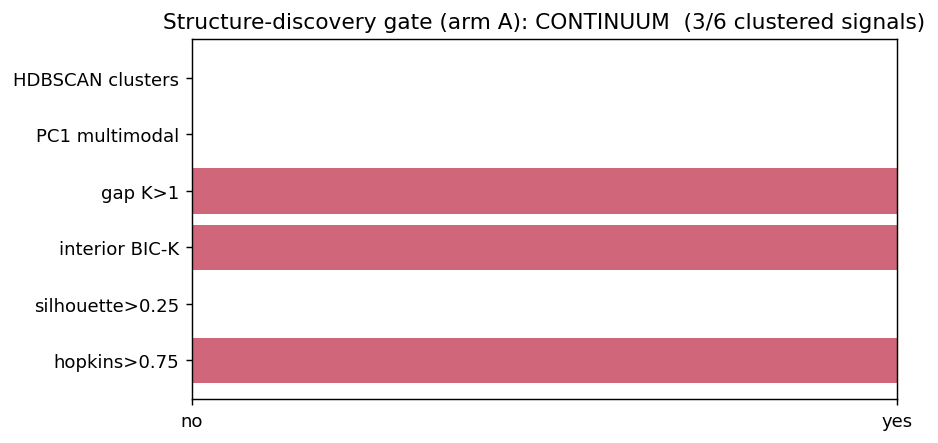

,value
hopkins,0.795033
silhouette_peak,0.139378
gmm_k_best,9
gmm_monotone,False
gap_k_opt,3
dip_pc1_p,0.990465
n_axes_multimodal,2
hdbscan_n,0
hdbscan_noise,1.0


In [4]:
v = state["structure"]["verdict_A"]
print("verdict (arm A):", v["label"].upper(), f"({v['clustered_score']}/{v['n_signals']} clustered signals)")
print("uncertainty-aware (over draws):", state["structure"]["uncertainty_A"])
display(Image(str(viz.structure_panel(state["structure"]))))
pd.Series(v["evidence"]).to_frame("value")

## 4. Soft operational regions (the lead view)

A measurement-error (Extreme-Deconvolution) mixture that propagates each patient's coordinate uncertainty.
The responsibilities are the **soft transition boundaries**; `K` is a deliberate operational granularity
choice (no natural K in a continuum), picked by the smallest-K-that-stays-confident-and-stable rule.

operational K: 2 — smallest K with confident-dominant>=0.5 and seed-ARI>=0.8


,bic,confident_dominant_frac,median_norm_entropy,seed_ari
K,,,,
2,197963.493,1.000,0.512,0.998
3,197917.655,0.924,0.596,0.968
4,198107.906,0.867,0.550,0.996
5,198345.357,0.840,0.490,0.972
6,198760.480,0.799,0.490,0.952
7,199188.411,0.758,0.484,0.966
8,199545.183,0.689,0.502,0.768


region labels: {0: 'near-average', 1: '↑suicidality'}


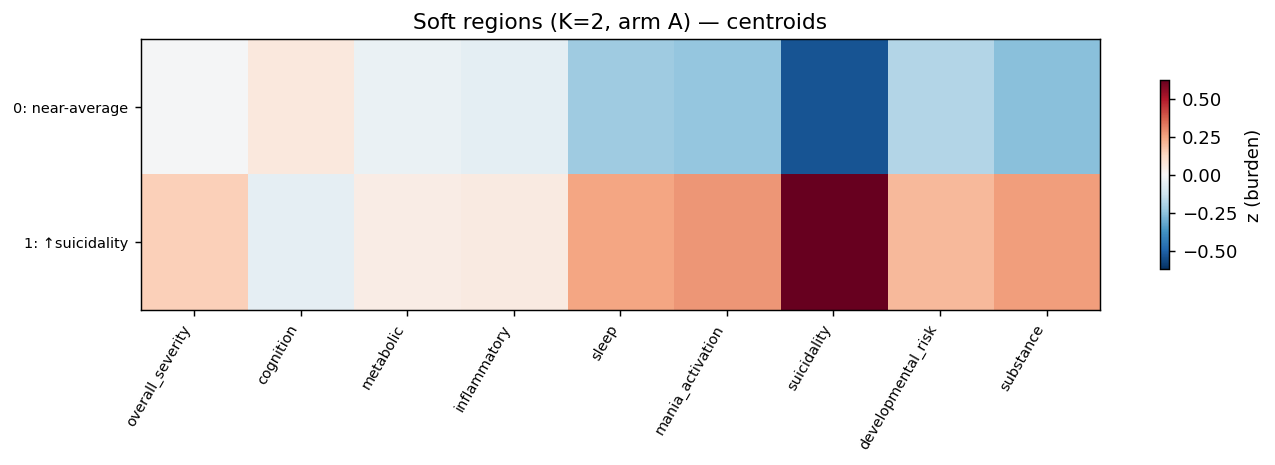

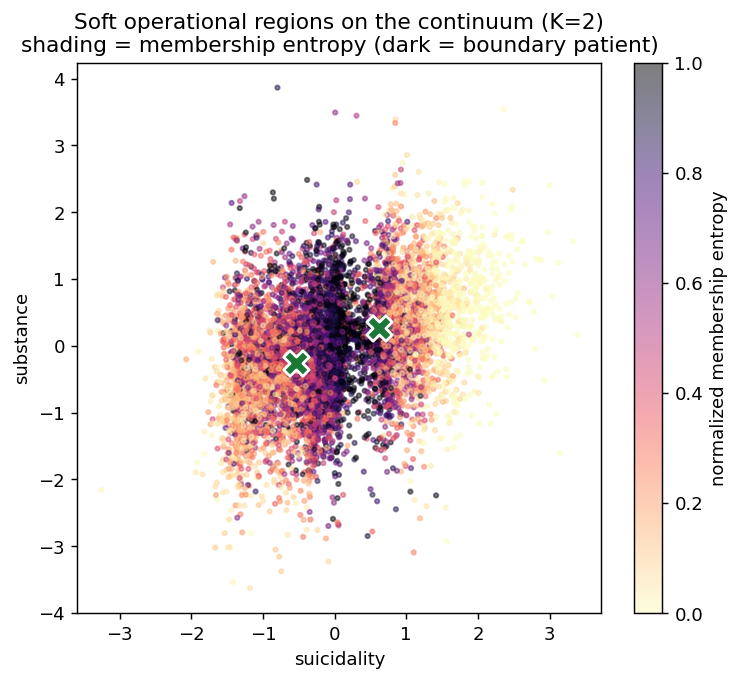

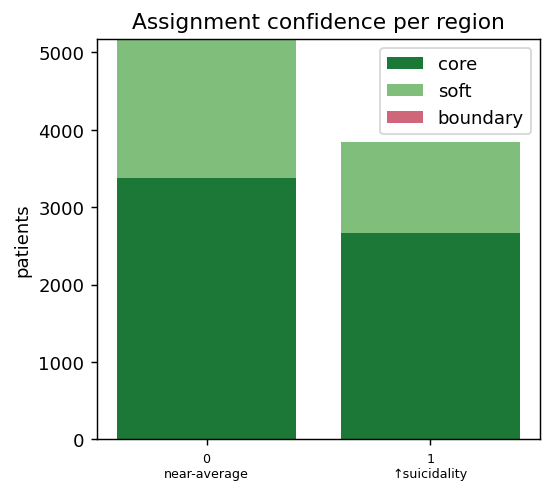

In [5]:
ck = state["choose_K"]
print("operational K:", ck["chosen_K"], "—", ck["rationale"])
display(pd.DataFrame(ck["sweep"]).set_index("K").round(3))
rf = state["region_A"]
print("region labels:", {k: rf.names[k] for k in range(rf.K)})
display(Image(str(viz.region_profiles(rf))))
display(Image(str(viz.boundary_map(coords, rf))))
display(Image(str(viz.confidence_bars(rf))))

## 5. Archetypes — the continuum co-view

Each patient is a convex blend of A extreme phenotypes (a simplex membership — no hard edges). This is the
continuum-honest representation that complements the operational tessellation.

A=4 archetypes · explained variance 0.52 · cross-seed stability (min Tucker) 0.979
archetype labels: {0: '↑substance ↑inflammatory ↑metabolic', 1: '↓overall_severity ↓developmental_risk ↓sleep', 2: '↓substance ↓inflammatory ↑overall_severity', 3: '↑sleep ↑developmental_risk ↓metabolic'}


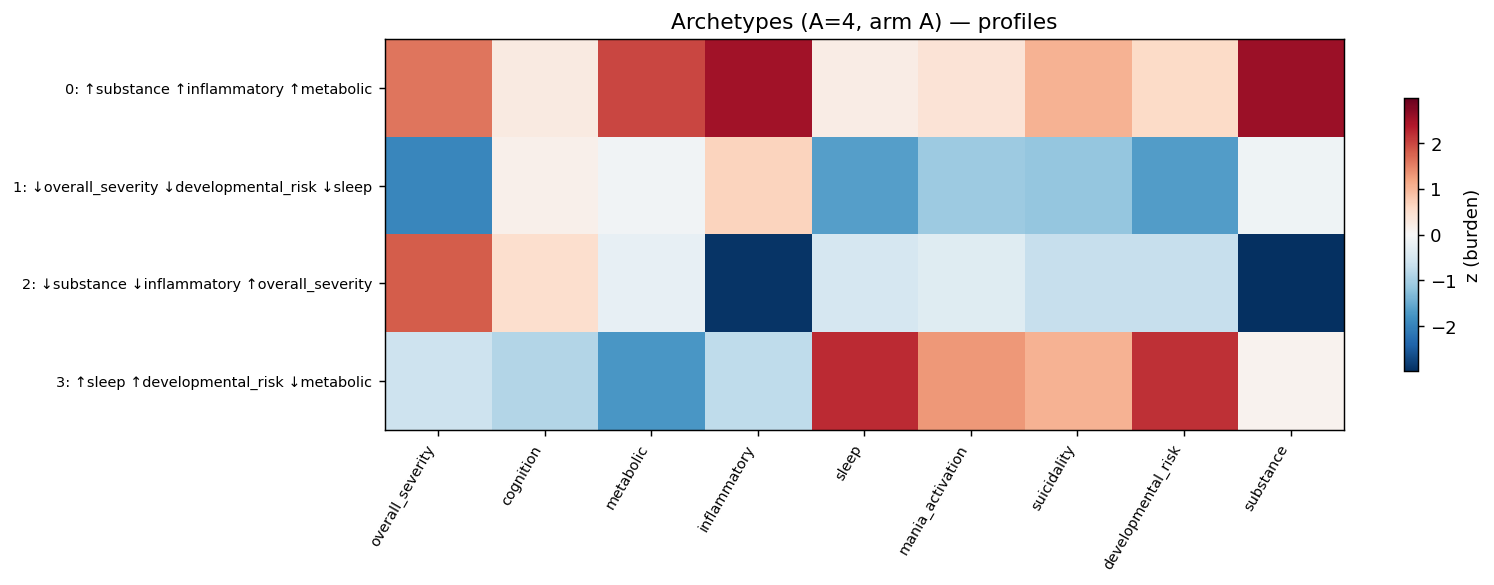

In [6]:
af = state["arch_A"]
print(f"A={af.A} archetypes · explained variance {af.explained_variance:.2f} · cross-seed stability "
      f"(min Tucker) {af.stability['min_tucker_congruence']:.3f}")
print("archetype labels:", {k: af.names[k] for k in range(af.A)})
display(Image(str(viz.archetype_profiles(af))))

## 6. Are the regions useful? (internal battery)

Assignment confidence (are patients assignable, or all 50/50?) · not-just-severity (Q2) · transdiagnostic
(Q3) · stable / not-a-missingness-artefact (Q4) · tighter than DSM-5. External and temporal validity are
deferred to the M3/M4 reruns.

In [7]:
u = state["usefulness"]
print("OVERALL:", u["summary"]["overall"], "| blockers:", u["summary"]["blockers"] or "none")
display(pd.DataFrame([
    {"criterion": "assignment", "gate": u["assignment"]["gate"],
     "detail": f"confident-dominant {u['assignment']['confident_dominant_frac']:.0%}, median entropy {u['assignment']['median_norm_entropy']:.2f}"},
    {"criterion": "not_just_severity", "gate": u["not_just_severity"]["gate"],
     "detail": f"eta2 specifics {u['not_just_severity']['mean_eta_specifics']:.3f} vs G {u['not_just_severity']['eta_G']:.3f}"},
    {"criterion": "transdiagnostic", "gate": u["transdiagnostic"]["gate"],
     "detail": f"ARI cohort {u['transdiagnostic']['ari_cohort']:.3f}, DSM-5 {u['transdiagnostic']['ari_dsm5']:.3f}"},
    {"criterion": "stable_not_artifact", "gate": u["stable_not_artifact"]["gate"],
     "detail": f"seed-ARI {u['stable_not_artifact']['seed_ari']['mean_ari']:.2f}, coverage perm-p {u['stable_not_artifact']['coverage_artifact']['perm_p_value']:.2f}"},
    {"criterion": "tighter_than_dsm5", "gate": u["tighter_than_dsm5"]["gate"],
     "detail": f"BIC {u['tighter_than_dsm5']['free_bic']:.0f} vs {u['tighter_than_dsm5']['dsm5_bic']:.0f}; eta2 {u['tighter_than_dsm5']['mean_eta_free']:.3f} vs {u['tighter_than_dsm5']['mean_eta_dsm5']:.3f}"},
]).set_index("criterion"))
# example boundary patients (living between regions)
b = state["patient_strata"]
display(b[b["tess_boundary"] == 1].head(5)[["cohort", "patient_id", "tess_MAP_name", "tess_entropy", "tess_confidence_tier"]])

OVERALL: PASS | blockers: none


,gate,detail
criterion,,
assignment,PASS,"confident-dominant 100%, median entropy 0.51"
not_just_severity,PASS,eta2 specifics 0.122 vs G 0.008
transdiagnostic,PASS,"ARI cohort -0.004, DSM-5 0.007"
stable_not_artifact,PASS,"seed-ARI 1.00, coverage perm-p 0.23"
tighter_than_dsm5,PASS,BIC 197963 vs 201294; eta2 0.109 vs 0.025


,cohort,patient_id,tess_MAP_name,tess_entropy,tess_confidence_tier


## 7. Hand-off + embedding

`patient_strata` carries the soft memberships + entropy + confidence tiers + boundary flags in the
M3-compatible contract (`arch_*` / `tess_*` columns + `arm`). The PCA embedding below is **visualization
only** — it confirms the regions are a soft overlay and that cohort / DSM-5 do not separate.

patient_strata: (9013, 23) | arch_/tess_ cols: 20


,cohort,patient_id,arch_w0,arch_w0_sd,arch_w1,arch_w1_sd,arch_w2,arch_w2_sd,arch_w3,arch_w3_sd,...,arch_confidence_tier,arch_boundary,tess_r0,tess_r1,tess_MAP,tess_MAP_name,tess_entropy,tess_confidence_tier,tess_boundary,arm
0,bp,10001,0.1775,0.1211,0.4033,0.0712,0.2790,0.1515,0.1403,0.0614,...,boundary,1,0.8637,0.1363,0,near-average,0.5746,core,0,Bipolaire de type 2
1,bp,10002,0.1513,0.1577,0.5581,0.0677,0.0581,0.1353,0.2325,0.0828,...,soft,0,0.8542,0.1458,0,near-average,0.5993,core,0,Bipolaire de type 1
2,bp,10003,0.0832,0.1276,0.5097,0.0824,0.0000,0.1065,0.4071,0.0835,...,soft,0,0.8721,0.1279,0,near-average,0.5515,core,0,Bipolaire de type 1
3,bp,10004,0.0000,0.0121,0.6747,0.0555,0.1435,0.0895,0.1818,0.0726,...,soft,0,0.9638,0.0362,0,near-average,0.2245,core,0,Bipolaire de type 1


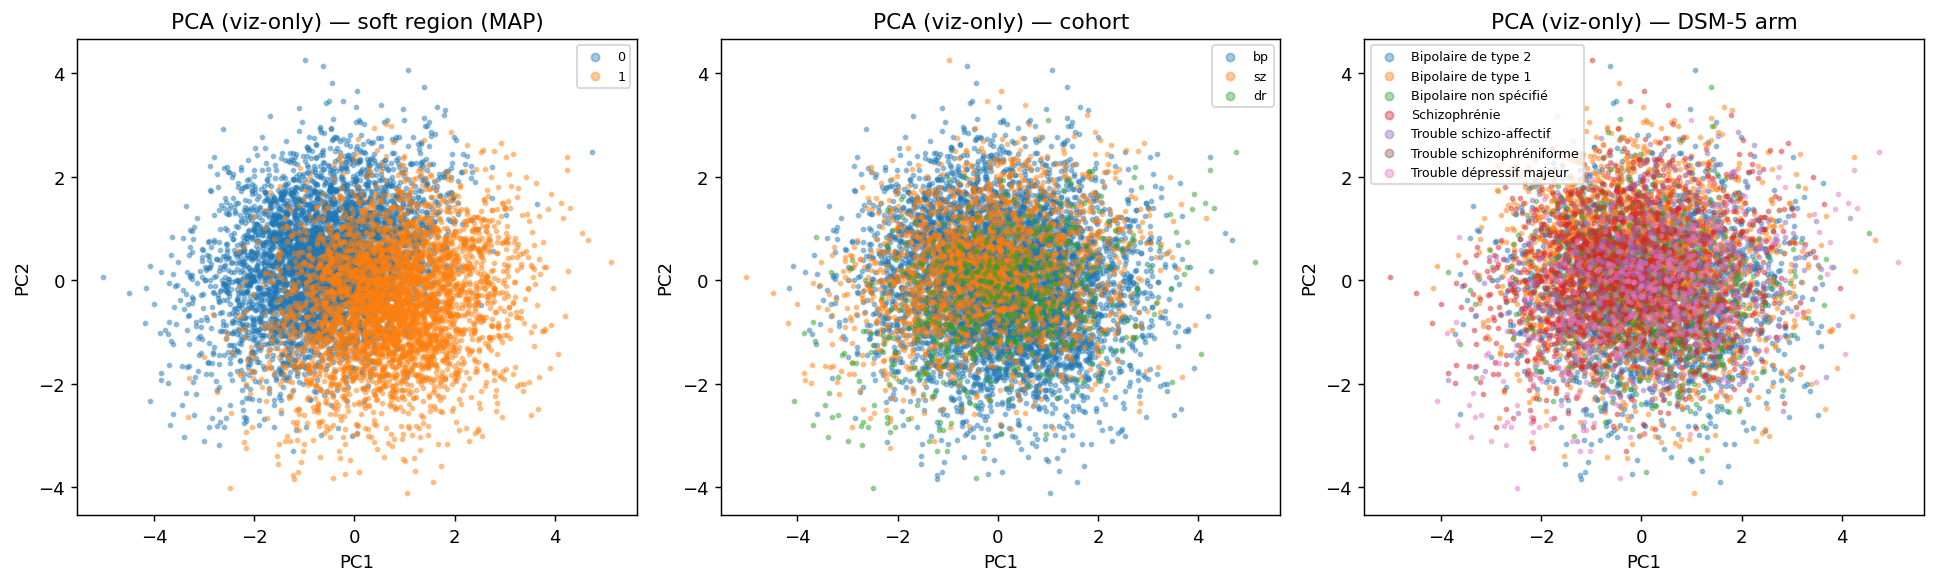

In [8]:
ps = state["patient_strata"]
print("patient_strata:", ps.shape, "| arch_/tess_ cols:", sum(c.startswith(("arch_", "tess_")) for c in ps.columns))
display(ps.head(4))
display(Image(str(viz.embedding(coords, state["region_A"]))))

## Notes

- **Continuum, not clusters** — the structure gate confirms it; the soft regions are an operational overlay.
- **Operational K is a deliberate choice** (no natural K): the smallest K that stays confidently assignable
  and stable. The archetypes give the finer continuum-honest description.
- **Soft boundaries are first-class**: entropy + core/soft/boundary tiers + a boundary flag per patient.
- This is **internal/baseline** usefulness. Temporal persistence (M3) and prognosis (M4) are the next reruns
  on this copula strata object.
- Reproduce: `python notebooks/run_strata_model_oop.py --mode full` then `strata_oop_make_figures.py`.